In [3]:
import numpy as np

data = np.load("lookup_table.npz")
T = data["T"]                  # (J,K,L)
prob_edges = data["prob_edges"]
coop_edges = data["coop_edges"]
error_levels = data["error_levels"]

print("T shape:", T.shape)
print("prob bins J:", len(prob_edges)-1, "coop bins K:", len(coop_edges)-1, "L:", len(error_levels))
print("error_levels min/max:", error_levels.min(), error_levels.max())

# somme sur j pour chaque (k,l)
S = T.sum(axis=0)  # shape (K,L)
print("sum_j t(j,k,l) stats: min/mean/max =", S.min(), S.mean(), S.max())

# combien de cellules (j,k,l) sont exactement 0 ?
zero_frac = (T == 0).mean()
print("fraction of zeros in T:", zero_frac)

print(T[:, :, 0])
print(T[:, :, -1])



T shape: (5, 5, 4)
prob bins J: 5 coop bins K: 5 L: 4
error_levels min/max: 0.1 1.5
sum_j t(j,k,l) stats: min/mean/max = 0.9999999999999999 1.0 1.0
fraction of zeros in T: 0.0
[[0.46428571 0.24615385 0.21088435 0.17886179 0.10493827]
 [0.25       0.23076923 0.2244898  0.10569106 0.01851852]
 [0.14285714 0.23076923 0.19047619 0.13821138 0.02469136]
 [0.07142857 0.12307692 0.16326531 0.08943089 0.01851852]
 [0.07142857 0.16923077 0.21088435 0.48780488 0.83333333]]
[[0.63333333 0.6122449  0.60839161 0.69512195 0.52941176]
 [0.23333333 0.16326531 0.1048951  0.08536585 0.00452489]
 [0.03333333 0.06122449 0.15384615 0.12195122 0.01357466]
 [0.06666667 0.10204082 0.0979021  0.04878049 0.00904977]
 [0.03333333 0.06122449 0.03496503 0.04878049 0.44343891]]


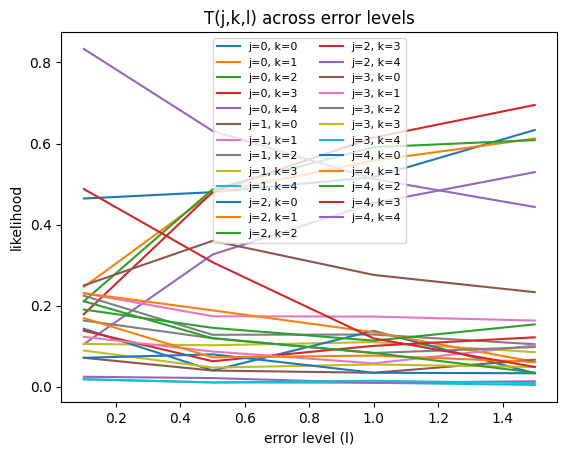

In [2]:
import matplotlib.pyplot as plt

for j in range(5):
    for k in range(5):
        plt.plot(error_levels, T[j, k, :], label=f"j={j}, k={k}")
plt.title("T(j,k,l) across error levels")
plt.xlabel("error level (l)")
plt.ylabel("likelihood")
plt.legend(ncol=2, fontsize=8)
plt.show()
